# Honey Yield Predictive Modeling Pipeline

This notebook develops a reproducible DuckDB workflow for preparing hive sensor data for predictive modeling. The project objective is to predict next-day hive weight change using historical hive measurements, environmental conditions, and available colony-event information.

The workflow follows a layered structure:

```text
Raw source data
      │
      ▼
DuckDB anchor tables
      │
      ▼
Clean measurement tables
      │
      ▼
Feature engineering
      │
      ▼
Modeling dataset
      │
      ▼
Predictive models

> Notebook Role: This is the clean project implementation notebook. Exploratory tests, debugging cells, and experimental modeling decisions are developed separately before being incorporated here.
>
> Development Note: This notebook was developed and validated using a representative subset of the daily hive measurements to enable rapid iteration during pipeline development. The workflow is designed to scale to the complete archive with minimal modification once feature engineering and modeling logic have been verified.

## 1. Project Setup

This section imports the required Python libraries and defines reusable project paths.

### 1.1 Imports

In [1]:
from pathlib import Path
import os

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from dotenv import load_dotenv

# Resolve repository paths regardless of whether the notebook is launched
# from the project root or from Stephanie_Work.
working_dir = Path.cwd().resolve()

if working_dir.name == "Stephanie_Work":
    project_root = working_dir.parent
else:
    project_root = working_dir

data_dir = project_root / "Data"
documentation_dir = project_root / "Documentation"
figures_dir = project_root / "Figures"
exports_dir = project_root / "Exports"

for directory in (
    data_dir,
    documentation_dir,
    figures_dir,
    exports_dir,
):
    directory.mkdir(parents=True, exist_ok=True)

print(f"Working directory: {working_dir}")
print(f"Project root:      {project_root}")
print(f"Data directory:   {data_dir}")

Working directory: C:\Users\sfnor\Miniconda3\envs\pandas_book\honey-yield-predictive-model\Stephanie_Work
Project root:      C:\Users\sfnor\Miniconda3\envs\pandas_book\honey-yield-predictive-model
Data directory:   C:\Users\sfnor\Miniconda3\envs\pandas_book\honey-yield-predictive-model\Data


### 1.2 Paths

In [2]:
database_path = data_dir / "honey.duckdb"

if not database_path.exists():
    raise FileNotFoundError(
        f"""
DuckDB database was not found.

Expected location:
{database_path}

Run the ETL pipeline (Honey_Project_Pipeline.ipynb) first to build the database.
"""
    )

print(f"Using DuckDB database:\n{database_path}")

Using DuckDB database:
C:\Users\sfnor\Miniconda3\envs\pandas_book\honey-yield-predictive-model\Data\honey.duckdb


### 1.3 Connect to local honey.duckdb

In [3]:
con = duckdb.connect(str(database_path))

print("Connected successfully.")

Connected successfully.


### 1.4 Attach Quack / bees

In [4]:
# --------------------------------------------------
# Shared Database Connection
# --------------------------------------------------

# Load environment variables
load_dotenv(dotenv_path="../.env")

quack_host = os.getenv("TAILNET_HOST")
quack_token = os.getenv("QUACK_TOKEN")

if not quack_host or not quack_token:
    raise RuntimeError(
        "TAILNET_HOST or QUACK_TOKEN was not found in the .env file."
    )

# Load required extensions into the existing DuckDB connection
con.execute("FORCE INSTALL quack")
con.execute("INSTALL httpfs")
con.execute("LOAD quack")
con.execute("LOAD httpfs")
con.execute("SET s3_region = 'us-east-1'")

# Attach the shared database
con.execute(f"""
ATTACH 'quack:{quack_host}' AS bees (
    TOKEN '{quack_token}',
    DISABLE_SSL true
)
""")

print("Connected to Quack DB successfully.")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Connected to Quack DB successfully.


### 1.5 Configure DuckDB Resources

In [5]:
temp_dir = project_root / "Data" / "duckdb_temp"
temp_dir.mkdir(parents=True, exist_ok=True)

con.execute("SET threads = 2;")
con.execute("SET memory_limit = '4GB';")
con.execute(f"SET temp_directory = '{temp_dir.as_posix()}';")
con.execute("SET preserve_insertion_order = false;")

print("DuckDB resource settings configured.")

DuckDB resource settings configured.


### 1.6 Load remote source data

The shared `bob_sensor_processed` table is queried through the Quack connection and materialized into the local DuckDB database. This creates a stable local source table for the downstream ETL and feature-engineering steps.

In [6]:
con.execute("""
CREATE OR REPLACE TABLE bob_sensor_source AS
SELECT *
FROM bees.query('
    SELECT *
    FROM bob_sensor_processed
    WHERE interval = ''d''
      AND dataset = ''years''
')
""")

source_summary = con.execute("""
SELECT
    COUNT(*) AS row_count,
    COUNT(DISTINCT source_file) AS source_file_count,
    MIN(CAST(time AS DATE)) AS start_date,
    MAX(CAST(time AS DATE)) AS end_date
FROM bob_sensor_source
""").df()

source_summary

,row_count,source_file_count,start_date,end_date
0,29172,78,2019-06-24,2022-12-31


## 2. Existing Pipeline Tables

DuckDB provides the analytical database layer for the project. Persistent tables stored in the database remain available after the notebook kernel is restarted.

In [7]:
con.execute("""
SHOW TABLES;
""").df()

,name
0,bob_sensor_source
1,honey_daily_clean
2,honey_daily_raw
3,honey_daily_summary
4,honey_feature_candidates


## 3. Remote Source Data Verification

This section verifies the shared daily hive dataset materialized from the remote `bob_sensor_processed` table before downstream transformations are created.

In [8]:
source_check = con.execute("""
SELECT
    COUNT(*) AS row_count,
    COUNT(DISTINCT source_file) AS source_files,
    MIN(CAST(time AS DATE)) AS start_date,
    MAX(CAST(time AS DATE)) AS end_date
FROM bob_sensor_source
""").df()

source_check

,row_count,source_files,start_date,end_date
0,29172,78,2019-06-24,2022-12-31


In [9]:
con.execute("""
SELECT *
FROM bob_sensor_source
ORDER BY time, source_file
LIMIT 5
""").df()

,dataset,category,interval,source_file,column00,time,t_i_1,t_i_2,t_i_3,t_i_4,...,died_last,died_next,died_last_dif,died_next_dif,swarming_last,swarming_next,swarming_last_dif,swarming_next_dif,lon,lat
0,years,2019,d,11.csv,1,2019-06-24,30.161716,30.385575,26.336027,26.089829,...,NaT,NaT,NaN,NaN,NaT,NaT,NaN,339.55,8.8,53.1
1,years,2019,d,11.csv,2,2019-06-25,31.245139,32.241493,29.988411,29.896354,...,NaT,NaT,NaN,NaN,NaT,NaT,NaN,338.958680555556,8.8,53.1
2,years,2019,d,11.csv,3,2019-06-26,30.267904,30.320530,27.155100,26.809896,...,NaT,NaT,NaN,NaN,NaT,NaT,NaN,337.958680555556,8.8,53.1
3,years,2019,d,11.csv,4,2019-06-27,26.206090,25.515725,18.621162,18.206491,...,NaT,NaT,NaN,NaN,NaT,NaT,NaN,336.993446379468,8.8,53.1
4,years,2019,d,11.csv,5,2019-06-28,26.814617,26.220755,15.983177,18.859013,...,NaT,NaT,NaN,NaN,NaT,NaT,NaN,336.263888888889,8.8,53.1


### Refactoring Note

The current anchor table is created from local CSV files collected during development.

The long-term reproducible pipeline will replace these local file references with the shared `bob_sensor_source` table materialized from the Quack database. The transformation logic below will be preserved while the data source is migrated.

## 4. Raw Anchor Table

The raw anchor table materializes the shared bob_sensor_source data into the local DuckDB database with minimal modification. This creates a stable input for downstream cleaning and feature engineering while preserving a reproducible connection to the shared source. The validation summary confirms the record count, source files, and date range after loading.

In [10]:
con.execute("""
CREATE OR REPLACE TABLE honey_daily_raw AS
SELECT *
FROM bob_sensor_source
""")

raw_summary = con.execute("""
SELECT
    COUNT(*) AS row_count,
    COUNT(DISTINCT source_file) AS source_file_count,
    MIN(CAST(time AS DATE)) AS start_date,
    MAX(CAST(time AS DATE)) AS end_date
FROM honey_daily_raw
""").df()

raw_summary

,row_count,source_file_count,start_date,end_date
0,29172,78,2019-06-24,2022-12-31


## 5. Clean Measurement Table

The shared source table already contains typed numeric and timestamp fields. This step standardizes column names, identifies column00 as the hive identifier, retains the environmental and event-related fields needed for downstream analysis, and removes records missing measurement time or hive weight. The resulting clean table contains 41,691 observations across 349 hives from June 2019 through December 2022.

In [11]:
con.execute("""
DESCRIBE honey_daily_raw;
""").df()

,column_name,column_type,null,key,default,extra
0,dataset,VARCHAR,YES,None,None,None
1,category,VARCHAR,YES,None,None,None
2,interval,VARCHAR,YES,None,None,None
3,source_file,VARCHAR,YES,None,None,None
4,column00,BIGINT,YES,None,None,None
5,time,TIMESTAMP,YES,None,None,None
6,t_i_1,DOUBLE,YES,None,None,None
7,t_i_2,DOUBLE,YES,None,None,None
8,t_i_3,DOUBLE,YES,None,None,None
9,t_i_4,DOUBLE,YES,None,None,None


In [12]:
con.execute("""
CREATE OR REPLACE TABLE honey_daily_clean AS
SELECT
    column00 AS source_row_id,
    CAST(time AS DATE) AS measurement_date,
    time AS measurement_time,

    weight_kg,
    weight_delta AS source_weight_delta_kg,

    t_i_1 AS internal_temp_1,
    t_i_2 AS internal_temp_2,
    t_i_3 AS internal_temp_3,
    t_i_4 AS internal_temp_4,
    t_i_5 AS internal_temp_5,

    t_o AS outside_temp,
    h AS humidity,
    p AS pressure,

    lat AS latitude,
    lon AS longitude,

    source_file AS source_filename,

    dataset,
    category,
    interval,
    key,
    event,
    no_jump,
    outlier_lim

FROM honey_daily_raw
WHERE time IS NOT NULL
  AND weight_kg IS NOT NULL;
""")

clean_summary = con.execute("""
SELECT
    COUNT(*) AS row_count,
    COUNT(DISTINCT source_filename) AS source_file_count,
    MIN(measurement_date) AS start_date,
    MAX(measurement_date) AS end_date
FROM honey_daily_clean
""").df()

clean_summary

,row_count,source_file_count,start_date,end_date
0,29155,78,2019-06-24,2022-12-31


In [13]:
con.execute("DESCRIBE honey_daily_clean").df()

,column_name,column_type,null,key,default,extra
0,source_row_id,BIGINT,YES,None,None,None
1,measurement_date,DATE,YES,None,None,None
2,measurement_time,TIMESTAMP,YES,None,None,None
3,weight_kg,DOUBLE,YES,None,None,None
4,source_weight_delta_kg,DOUBLE,YES,None,None,None
5,internal_temp_1,DOUBLE,YES,None,None,None
6,internal_temp_2,DOUBLE,YES,None,None,None
7,internal_temp_3,DOUBLE,YES,None,None,None
8,internal_temp_4,DOUBLE,YES,None,None,None
9,internal_temp_5,DOUBLE,YES,None,None,None


In [14]:
con.execute("""
SELECT
    (SELECT COUNT(*) FROM honey_daily_raw) AS raw_rows,
    (SELECT COUNT(*) FROM honey_daily_clean) AS clean_rows;
""").df()

,raw_rows,clean_rows
0,29172,29155


In [15]:
con.execute("""
WITH daily_counts AS (
    SELECT
        source_filename,
        CAST(measurement_time AS DATE) AS measurement_date,
        COUNT(*) AS readings_per_day
    FROM honey_daily_clean
    GROUP BY
        source_filename,
        CAST(measurement_time AS DATE)
)

SELECT
    MIN(readings_per_day) AS minimum_readings_per_day,
    MAX(readings_per_day) AS maximum_readings_per_day,
    COUNT(*) AS hive_date_records
FROM daily_counts;
""").df()

,minimum_readings_per_day,maximum_readings_per_day,hive_date_records
0,1,1,29155


## 6. Daily Hive Summary

This section creates one standardized daily observation per hive using the cleaned shared dataset. Because the source is already at daily grain, no additional aggregation is required. The table retains the end-of-day hive weight, environmental measurements, location fields, and source metadata needed for feature engineering.

In [16]:
con.execute("""
CREATE OR REPLACE TABLE honey_daily_summary AS
SELECT
    TRY_CAST(
        regexp_extract(
            source_filename,
            '([0-9]+)\\.csv$',
            1
        ) AS INTEGER
    ) AS hive_id,

    measurement_date,

    weight_kg AS end_of_day_weight_kg,

    internal_temp_1 AS avg_internal_temp_1,
    internal_temp_2 AS avg_internal_temp_2,
    internal_temp_3 AS avg_internal_temp_3,
    internal_temp_4 AS avg_internal_temp_4,
    internal_temp_5 AS avg_internal_temp_5,

    outside_temp AS avg_outside_temp,
    humidity AS avg_humidity,
    pressure AS avg_pressure,

    latitude,
    longitude,
    source_filename

FROM honey_daily_clean;
""")

print("Created daily summary table: honey_daily_summary")

Created daily summary table: honey_daily_summary


In [17]:
summary_check = con.execute("""
SELECT
    COUNT(*) AS row_count,
    COUNT(DISTINCT hive_id) AS hive_count,
    COUNT(*) - COUNT(hive_id) AS missing_hive_ids,
    MIN(measurement_date) AS start_date,
    MAX(measurement_date) AS end_date
FROM honey_daily_summary
""").df()

summary_check

,row_count,hive_count,missing_hive_ids,start_date,end_date
0,29155,78,0,2019-06-24,2022-12-31


In [18]:
con.execute("""
SELECT COUNT(*) AS duplicate_hive_dates
FROM (
    SELECT
        hive_id,
        measurement_date
    FROM honey_daily_summary
    GROUP BY
        hive_id,
        measurement_date
    HAVING COUNT(*) > 1
)
""").df()

,duplicate_hive_dates
0,0


## 7. Feature Engineering

Historical features are calculated independently within each hive using SQL window functions. These variables represent recent hive conditions and temporal trends that may help predict the next day's weight change.

In [19]:
con.execute("""
CREATE OR REPLACE TABLE honey_feature_candidates AS

WITH weight_windows AS (
    SELECT
        hive_id,
        measurement_date,
        end_of_day_weight_kg,

        LAG(measurement_date) OVER (
            PARTITION BY hive_id
            ORDER BY measurement_date
        ) AS previous_observation_date,

        LEAD(measurement_date) OVER (
            PARTITION BY hive_id
            ORDER BY measurement_date
        ) AS next_observation_date,

        LAG(end_of_day_weight_kg) OVER (
            PARTITION BY hive_id
            ORDER BY measurement_date
        ) AS previous_day_weight_kg,

        LEAD(end_of_day_weight_kg) OVER (
            PARTITION BY hive_id
            ORDER BY measurement_date
        ) AS next_day_weight_kg,

        AVG(end_of_day_weight_kg) OVER (
            PARTITION BY hive_id
            ORDER BY measurement_date
            ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
        ) AS rolling_3_day_weight_kg,

        AVG(end_of_day_weight_kg) OVER (
            PARTITION BY hive_id
            ORDER BY measurement_date
            ROWS BETWEEN 6 PRECEDING AND CURRENT ROW
        ) AS rolling_7_day_weight_kg

    FROM honey_daily_summary
),

engineered_weights AS (
    SELECT
        *,

        DATE_DIFF(
            'day',
            previous_observation_date,
            measurement_date
        ) AS days_since_previous_observation,

        DATE_DIFF(
            'day',
            measurement_date,
            next_observation_date
        ) AS days_to_next_observation,

        end_of_day_weight_kg
            - previous_day_weight_kg
            AS previous_day_weight_change_kg,

        next_day_weight_kg
            - end_of_day_weight_kg
            AS target_next_day_weight_change_kg

    FROM weight_windows
)

SELECT
    e.hive_id,
    e.measurement_date,
    e.end_of_day_weight_kg,
    e.previous_observation_date,
    e.next_observation_date,
    e.previous_day_weight_kg,
    e.next_day_weight_kg,
    e.rolling_3_day_weight_kg,
    e.rolling_7_day_weight_kg,
    e.days_since_previous_observation,
    e.days_to_next_observation,
    e.previous_day_weight_change_kg,
    e.target_next_day_weight_change_kg,

    s.avg_internal_temp_1,
    s.avg_internal_temp_2,
    s.avg_internal_temp_3,
    s.avg_internal_temp_4,
    s.avg_internal_temp_5,
    s.avg_outside_temp,
    s.avg_humidity,
    s.avg_pressure,
    s.latitude,
    s.longitude,
    s.source_filename,

    EXTRACT(YEAR FROM e.measurement_date) AS year,
    EXTRACT(MONTH FROM e.measurement_date) AS month,
    EXTRACT(DOY FROM e.measurement_date) AS day_of_year

FROM engineered_weights AS e

LEFT JOIN honey_daily_summary AS s
    ON e.hive_id = s.hive_id
   AND e.measurement_date = s.measurement_date;
""")

print("Created feature candidate table: honey_feature_candidates")

Created feature candidate table: honey_feature_candidates


In [20]:
con.execute("""
SELECT
    COUNT(*) AS feature_rows,
    COUNT(DISTINCT hive_id) AS hive_count,
    MIN(measurement_date) AS first_date,
    MAX(measurement_date) AS last_date
FROM honey_feature_candidates;
""").df()

,feature_rows,hive_count,first_date,last_date
0,29155,78,2019-06-24,2022-12-31


> **Window-Function Logic**
>
> `PARTITION BY hive_id` restarts each calculation for every hive. `LAG()` retrieves the previous available observation, while `LEAD()` retrieves the following observation. Calendar-gap fields are retained so that only true consecutive-day records are used in the final modeling dataset.

## 8. Modeling Dataset

The final modeling table retains records with valid previous-day and next-day observations. Extreme weight changes are flagged for analysis rather than automatically removed.

In [21]:
con.execute("""
CREATE OR REPLACE TABLE honey_model AS
SELECT
    *,

    CASE
        WHEN ABS(target_next_day_weight_change_kg) > 5
        THEN TRUE
        ELSE FALSE
    END AS extreme_weight_change_flag

FROM honey_feature_candidates

WHERE days_since_previous_observation = 1
  AND days_to_next_observation = 1
  AND end_of_day_weight_kg IS NOT NULL
  AND previous_day_weight_kg IS NOT NULL
  AND next_day_weight_kg IS NOT NULL
  AND end_of_day_weight_kg > 0
  AND previous_day_weight_kg > 0
  AND next_day_weight_kg > 0
  AND target_next_day_weight_change_kg IS NOT NULL;
""");

print("Created final modeling table: honey_model")

Created final modeling table: honey_model


In [22]:
con.execute("""
SELECT
    COUNT(*) AS observations,
    COUNT(DISTINCT hive_id) AS hives,
    MIN(measurement_date) AS first_date,
    MAX(measurement_date) AS last_date,
    AVG(target_next_day_weight_change_kg) AS average_target_change
FROM honey_model;
""").df()

,observations,hives,first_date,last_date,average_target_change
0,26215,78,2019-06-25,2022-12-30,0.002042


In [23]:
con.execute("""
SELECT
    COUNT(*) AS duplicate_hive_dates
FROM (
    SELECT
        hive_id,
        measurement_date,
        COUNT(*) AS row_count
    FROM honey_model
    GROUP BY
        hive_id,
        measurement_date
    HAVING COUNT(*) > 1
);
""").df()

,duplicate_hive_dates
0,0


## 9. Preliminary Analysis

This section explores the modeling dataset, summarizes the target variable, investigates routine and extreme next-day hive weight changes, and evaluates whether the available data are sufficient to support the project's predictive modeling objectives.

## 9.1 Modeling Dataset Overview

The final modeling dataset contains 26,215 daily observations across 78 individual hives collected between June 2019 and December 2022. Twenty-seven engineered variables describe historical hive weight, environmental conditions, temporal information, and the prediction target used for modeling.

In [24]:
model_df = con.execute("""
SELECT *
FROM honey_model
ORDER BY
    hive_id,
    measurement_date
""").df()

print(f"Modeling observations: {len(model_df):,}")
print(f"Features: {model_df.shape[1]}")
print(f"Hives: {model_df['hive_id'].nunique():,}")

model_df.head()

Modeling observations: 26,215
Features: 28
Hives: 78


,hive_id,measurement_date,end_of_day_weight_kg,previous_observation_date,next_observation_date,previous_day_weight_kg,next_day_weight_kg,rolling_3_day_weight_kg,rolling_7_day_weight_kg,days_since_previous_observation,...,avg_outside_temp,avg_humidity,avg_pressure,latitude,longitude,source_filename,year,month,day_of_year,extreme_weight_change_flag
0,0,2020-01-27,10.707553,2020-01-26,2020-01-28,10.703729,10.451762,10.705641,10.705641,1,...,15.886795,44.609938,984.846073,51.9,8.9,0.csv,2020,1,27,False
1,0,2020-02-04,20.194028,2020-02-03,2020-02-05,20.192441,20.092258,20.223938,16.103468,1,...,1.605729,67.816944,990.499926,51.9,8.9,0.csv,2020,2,35,False
2,0,2020-02-05,20.092258,2020-02-04,2020-02-06,20.194028,20.028208,20.159576,17.444686,1,...,0.804688,68.146470,1010.646980,51.9,8.9,0.csv,2020,2,36,False
3,0,2020-02-06,20.028208,2020-02-05,2020-02-07,20.092258,19.982071,20.104831,18.776209,1,...,1.715321,77.441748,1009.151647,51.9,8.9,0.csv,2020,2,37,False
4,0,2020-02-07,19.982071,2020-02-06,2020-02-08,20.028208,19.912548,20.034179,20.137681,1,...,2.338498,67.460406,1005.561011,51.9,8.9,0.csv,2020,2,38,False


In [25]:
summary = pd.DataFrame({
    "Metric": [
        "Observations",
        "Features",
        "Unique hives",
        "Start date",
        "End date"
    ],
    "Value": [
        len(model_df),
        model_df.shape[1],
        model_df["hive_id"].nunique(),
        model_df["measurement_date"].min(),
        model_df["measurement_date"].max()
    ]
})

summary

,Metric,Value
0,Observations,26215
1,Features,28
2,Unique hives,78
3,Start date,2019-06-25 00:00:00
4,End date,2022-12-30 00:00:00


In [26]:
model_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 26215 entries, 0 to 26214
Data columns (total 28 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   hive_id                           26215 non-null  int32         
 1   measurement_date                  26215 non-null  datetime64[us]
 2   end_of_day_weight_kg              26215 non-null  float64       
 3   previous_observation_date         26215 non-null  datetime64[us]
 4   next_observation_date             26215 non-null  datetime64[us]
 5   previous_day_weight_kg            26215 non-null  float64       
 6   next_day_weight_kg                26215 non-null  float64       
 7   rolling_3_day_weight_kg           26215 non-null  float64       
 8   rolling_7_day_weight_kg           26215 non-null  float64       
 9   days_since_previous_observation   26215 non-null  int64         
 10  days_to_next_observation          26215 non-null  int64  

In [27]:
model_df.describe().T

,count,mean,min,25%,50%,75%,max,std
hive_id,26215.0,81.860309,0.0,58.0,84.0,109.0,152.0,36.98406
measurement_date,26215,2021-06-20 07:06:58.432195,2019-06-25 00:00:00,2020-10-02 00:00:00,2021-06-17 00:00:00,2022-03-08 00:00:00,2022-12-30 00:00:00,NaN
end_of_day_weight_kg,26215.0,34.303424,0.000528,24.420404,34.152745,43.17377,111.726537,14.666927
previous_observation_date,26215,2021-06-19 07:06:58.432195,2019-06-24 00:00:00,2020-10-01 00:00:00,2021-06-16 00:00:00,2022-03-07 00:00:00,2022-12-29 00:00:00,NaN
next_observation_date,26215,2021-06-21 07:06:58.432195,2019-06-26 00:00:00,2020-10-03 00:00:00,2021-06-18 00:00:00,2022-03-09 00:00:00,2022-12-31 00:00:00,NaN
previous_day_weight_kg,26215.0,34.290727,0.000528,24.415436,34.155444,43.146354,111.726537,14.663018
next_day_weight_kg,26215.0,34.305465,0.000528,24.424968,34.149082,43.184844,111.726537,14.679795
rolling_3_day_weight_kg,26215.0,34.289624,-0.260203,24.431665,34.155047,43.116961,111.450212,14.604208
rolling_7_day_weight_kg,26215.0,34.271409,-3.609844,24.459574,34.189855,43.089679,110.550571,14.510932
days_since_previous_observation,26215.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0


## 9.2 Target Variable Summary

The prediction target is the next-day hive weight change. Before fitting predictive models, the distribution of this variable was examined to understand its central tendency, variability, and range. These summary statistics provide context for interpreting model performance and identifying unusually large weight changes.

In [28]:
con.execute("""
SELECT
    AVG(target_next_day_weight_change_kg) AS mean_change,
    MEDIAN(target_next_day_weight_change_kg) AS median_change,
    STDDEV(target_next_day_weight_change_kg) AS standard_deviation,
    MIN(target_next_day_weight_change_kg) AS minimum_change,
    MAX(target_next_day_weight_change_kg) AS maximum_change
FROM honey_model;
""").df()

,mean_change,median_change,standard_deviation,minimum_change,maximum_change
0,0.002042,-0.044655,1.840522,-65.32294,39.098176


#### Interpretation

The target variable is centered close to zero (mean = 0.002 kg), indicating that most day-to-day hive weight changes are relatively small. However, the wide range (-65.32 kg to 39.10 kg) suggests the presence of infrequent but substantial weight-change events that warrant separate investigation.

## 9.3 Extreme Event Distribution

Although most next-day weight changes are relatively small, a small proportion represent unusually large increases or decreases. The following analysis quantifies the frequency of these extreme events and motivates investigating them separately from routine hive behavior.

In [29]:
con.execute("""
SELECT
    extreme_weight_change_flag,
    COUNT(*) AS observations,
    ROUND(
        100.0 * COUNT(*) / SUM(COUNT(*)) OVER (),
        2
    ) AS percentage
FROM honey_model
GROUP BY extreme_weight_change_flag
ORDER BY extreme_weight_change_flag;
""").df()

,extreme_weight_change_flag,observations,percentage
0,False,25770,98.3
1,True,445,1.7


#### Interpretation

Only 1.7% of observations were classified as extreme weight-change events, while 98.3% represented routine daily fluctuations. Although these extreme events are uncommon, they are large enough to substantially influence predictive model performance and therefore warrant separate investigation.

## 9.4 Investigating Extreme Events
    - Which hives?
    - Which dates?
    - Time-series plots

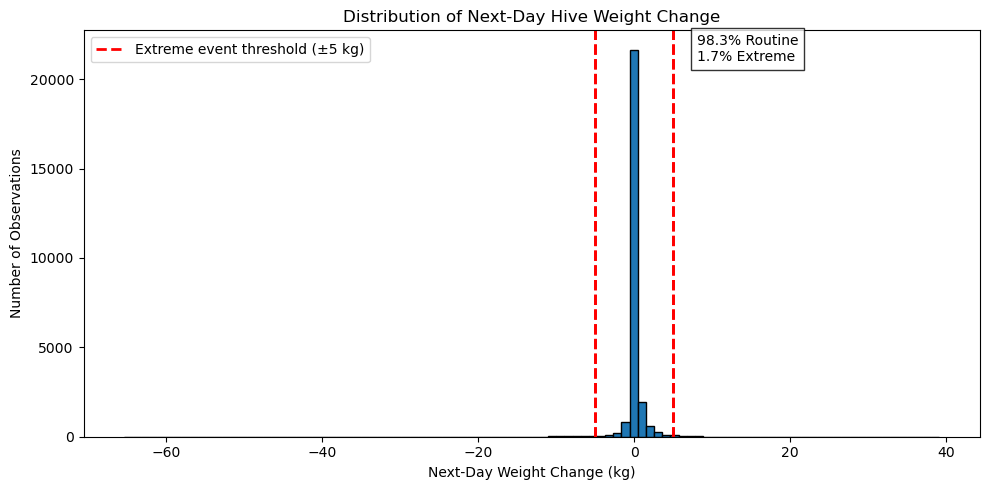

In [30]:
plt.figure(figsize=(10, 5))

plt.hist(
    model_df["target_next_day_weight_change_kg"],
    bins=100,
    edgecolor="black"
)

plt.axvline(-5, color="red", linestyle="--", linewidth=2)
plt.axvline(5, color="red", linestyle="--", linewidth=2)

plt.title("Distribution of Next-Day Hive Weight Change")
plt.xlabel("Next-Day Weight Change (kg)")
plt.ylabel("Number of Observations")

plt.text(
    8,
    21000,
    "98.3% Routine\n1.7% Extreme",
    fontsize=10,
    bbox=dict(facecolor="white", alpha=0.8)
)

plt.axvline(
    -5,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Extreme event threshold (±5 kg)"
)

plt.axvline(
    5,
    color="red",
    linestyle="--",
    linewidth=2
)

plt.legend()

plt.tight_layout()
plt.show()

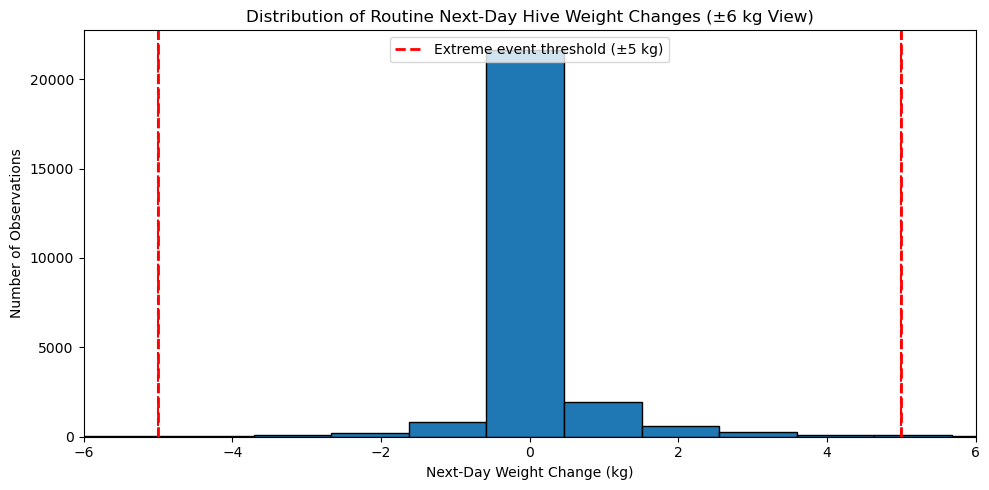

In [31]:
plt.figure(figsize=(10,5))

plt.hist(
    model_df["target_next_day_weight_change_kg"],
    bins=100,
    edgecolor="black"
)

plt.xlim(-6, 6)

plt.axvline(-5, color="red", linestyle="--")
plt.axvline(5, color="red", linestyle="--")

plt.title("Distribution of Routine Next-Day Hive Weight Changes (±6 kg View)")
plt.xlabel("Next-Day Weight Change (kg)")
plt.ylabel("Number of Observations")

plt.axvline(
    -5,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Extreme event threshold (±5 kg)"
)

plt.axvline(
    5,
    color="red",
    linestyle="--",
    linewidth=2
)

plt.legend()

plt.tight_layout()
plt.show()

#### Interpretation

The full distribution is centered near zero, indicating that most colonies experience relatively small day-to-day weight changes. However, the long tails on both sides of the distribution reveal a small number of unusually large gains and losses. Although these observations account for only 1.7% of the dataset, they have the potential to disproportionately influence predictive model performance. The following section investigates where and when these extreme events occur.

## 9.5 Feature Importance

Random Forest models estimate the relative importance of each predictor by measuring how much each variable reduces prediction error across the ensemble of decision trees. Examining feature importance provides insight into which variables contribute most to predicting next-day hive weight changes and helps guide future feature engineering efforts.


In [32]:
from sklearn.ensemble import RandomForestRegressor

feature_columns = [
    "previous_day_weight_kg",
    "rolling_3_day_weight_kg",
    "rolling_7_day_weight_kg",
    "avg_internal_temp_1",
    "avg_internal_temp_2",
    "avg_internal_temp_3",
    "avg_internal_temp_4",
    "avg_outside_temp",
    "avg_humidity",
    "avg_pressure",
    "day_of_year",
    "month"
]

X = model_df[feature_columns].ffill()
y = model_df["target_next_day_weight_change_kg"]

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

_ = rf.fit(X, y)

print("Random Forest trained successfully.")

Random Forest trained successfully.


>This Random Forest was fitted to the complete modeling dataset solely to examine global feature-importance patterns. Predictive performance is evaluated separately using a chronological train/test split.

In [33]:
importance_df = (
    pd.DataFrame({
        "Feature": feature_columns,
        "Importance": rf.feature_importances_
    })
    .sort_values("Importance", ascending=False)
)

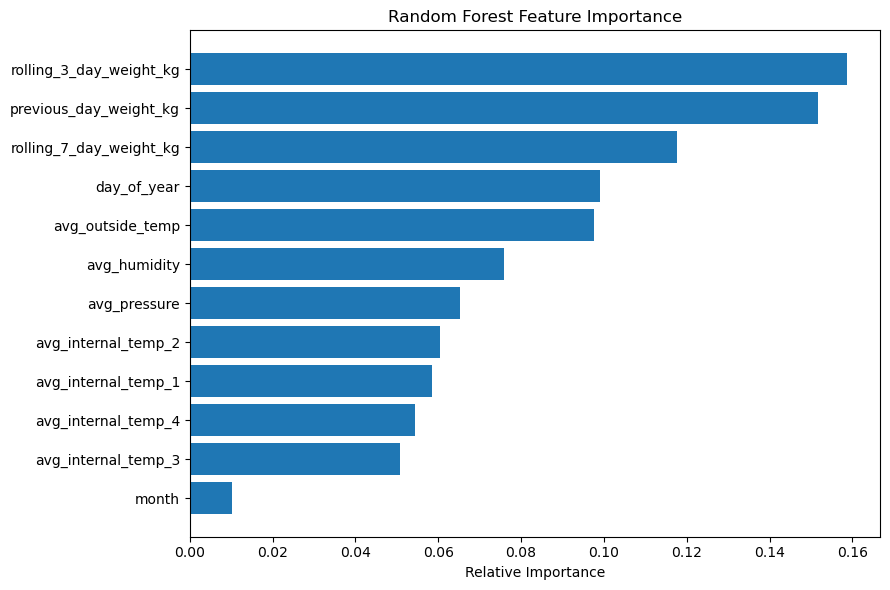

In [34]:
plt.figure(figsize=(9,6))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Relative Importance")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### Interpretation

The Random Forest model indicates that historical hive weight measurements are the strongest predictors of next-day hive weight change. The three most influential variables are the previous day's weight together with the 3-day and 7-day rolling averages, suggesting that recent colony behavior contains the greatest predictive information. Seasonal timing, represented by day of year, is also an important predictor, while environmental measurements such as outside temperature, humidity, pressure, and internal hive temperatures provide additional predictive value. These results support the project's feature engineering strategy and suggest that incorporating NOAA weather variables may further improve model performance.

### 9.6 Preliminary Conclusions

This preliminary analysis indicates that the available data are sufficient to support the project's initial modeling objectives. The modeling dataset contains 26,215 daily observations collected from 78 hives over approximately three and a half years, providing adequate temporal coverage for developing and evaluating baseline predictive models.

Exploratory analysis showed that next-day hive weight changes are centered near zero, with most observations representing relatively small day-to-day fluctuations. However, approximately 1.7% of observations were identified as extreme weight-change events. Although rare, these observations span a much wider range than routine daily changes and have the potential to disproportionately influence predictive model performance. This finding supports evaluating routine and extreme events separately during subsequent modeling.

Feature importance analysis further demonstrated that historical hive behavior provides the strongest predictive signal. Previous-day weight together with the 3-day and 7-day rolling averages were the most influential variables, while environmental measurements and seasonal timing contributed additional predictive information. These results validate the feature engineering strategy implemented in the DuckDB pipeline and suggest that incorporating NOAA weather observations and beekeeper records may further improve predictive performance.

Overall, the current workflow establishes a reproducible end-to-end modeling pipeline that progresses from raw measurements through feature engineering, exploratory analysis, and preliminary model interpretation. The next phase of the project will focus on expanding the feature set, integrating external weather data, investigating extreme events in greater detail, and comparing additional machine learning models using a chronological evaluation framework.

# Appendix A: Honey Model Schema

The following output documents the structure of the final `honey_model` table used for predictive modeling. This appendix is included for reproducibility and to assist project collaborators integrating the modeling dataset.

In [35]:
schema_df = con.execute("""
DESCRIBE honey_model;
""").df()

schema_df

,column_name,column_type,null,key,default,extra
0,hive_id,INTEGER,YES,None,None,None
1,measurement_date,DATE,YES,None,None,None
2,end_of_day_weight_kg,DOUBLE,YES,None,None,None
3,previous_observation_date,DATE,YES,None,None,None
4,next_observation_date,DATE,YES,None,None,None
5,previous_day_weight_kg,DOUBLE,YES,None,None,None
6,next_day_weight_kg,DOUBLE,YES,None,None,None
7,rolling_3_day_weight_kg,DOUBLE,YES,None,None,None
8,rolling_7_day_weight_kg,DOUBLE,YES,None,None,None
9,days_since_previous_observation,BIGINT,YES,None,None,None
